In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Test") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Student Performance Analysis") \
    .getOrCreate()

print("Spark Session Created")

Spark Session Created


In [3]:
df = spark.read.csv(
    "../dataset/students.csv",
    header=True,
    inferSchema=True
)

df.show()

+---+-------+----------+-----+
| ID|   Name|Department|Marks|
+---+-------+----------+-----+
|  1|    Ali|        CS|   85|
|  2|   Sara|        IT|   90|
|  3|  Ahmed|        SE|   78|
|  4| Ayesha|        CS|   92|
|  5|  Hamza|        IT|   67|
|  6|   Zain|        SE|   88|
|  7|   Hina|        CS|   75|
|  8|  Usman|        IT|   95|
|  9|  Maria|        SE|   80|
| 10| Faizan|        CS|   70|
| 11|  Bilal|        CS|   82|
| 12|   Noor|        IT|   76|
| 13|Daniyal|        SE|   89|
| 14|   Iqra|        CS|   91|
| 15|  Talha|        IT|   73|
| 16|  Maham|        SE|   84|
| 17|   Saad|        CS|   68|
| 18|   Eman|        IT|   87|
| 19|  Rafay|        SE|   79|
| 20|  Laiba|        CS|   94|
+---+-------+----------+-----+
only showing top 20 rows


In [4]:
df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Department: string (nullable = true)
 |-- Marks: integer (nullable = true)



In [5]:
clean_df = df.dropna()

clean_df.show()

+---+-------+----------+-----+
| ID|   Name|Department|Marks|
+---+-------+----------+-----+
|  1|    Ali|        CS|   85|
|  2|   Sara|        IT|   90|
|  3|  Ahmed|        SE|   78|
|  4| Ayesha|        CS|   92|
|  5|  Hamza|        IT|   67|
|  6|   Zain|        SE|   88|
|  7|   Hina|        CS|   75|
|  8|  Usman|        IT|   95|
|  9|  Maria|        SE|   80|
| 10| Faizan|        CS|   70|
| 11|  Bilal|        CS|   82|
| 12|   Noor|        IT|   76|
| 13|Daniyal|        SE|   89|
| 14|   Iqra|        CS|   91|
| 15|  Talha|        IT|   73|
| 16|  Maham|        SE|   84|
| 17|   Saad|        CS|   68|
| 18|   Eman|        IT|   87|
| 19|  Rafay|        SE|   79|
| 20|  Laiba|        CS|   94|
+---+-------+----------+-----+
only showing top 20 rows


In [6]:
avg_marks = clean_df.groupBy("Department").avg("Marks")

avg_marks.show()

+----------+-----------------+
|Department|       avg(Marks)|
+----------+-----------------+
|        IT|82.84615384615384|
|        SE|81.38461538461539|
|        CS|80.92857142857143|
+----------+-----------------+



In [7]:
top_students = clean_df.orderBy(
    clean_df.Marks.desc()
)

top_students.show(5)

+---+-------+----------+-----+
| ID|   Name|Department|Marks|
+---+-------+----------+-----+
| 36| Fatima|        IT|   96|
|  8|  Usman|        IT|   95|
| 20|  Laiba|        CS|   94|
| 24|Mehwish|        IT|   93|
|  4| Ayesha|        CS|   92|
+---+-------+----------+-----+
only showing top 5 rows


In [8]:
from pyspark.sql.functions import when

result_df = clean_df.withColumn(
    "Result",
    when(clean_df.Marks >= 50, "Pass")
    .otherwise("Fail")
)

result_df.show()

+---+-------+----------+-----+------+
| ID|   Name|Department|Marks|Result|
+---+-------+----------+-----+------+
|  1|    Ali|        CS|   85|  Pass|
|  2|   Sara|        IT|   90|  Pass|
|  3|  Ahmed|        SE|   78|  Pass|
|  4| Ayesha|        CS|   92|  Pass|
|  5|  Hamza|        IT|   67|  Pass|
|  6|   Zain|        SE|   88|  Pass|
|  7|   Hina|        CS|   75|  Pass|
|  8|  Usman|        IT|   95|  Pass|
|  9|  Maria|        SE|   80|  Pass|
| 10| Faizan|        CS|   70|  Pass|
| 11|  Bilal|        CS|   82|  Pass|
| 12|   Noor|        IT|   76|  Pass|
| 13|Daniyal|        SE|   89|  Pass|
| 14|   Iqra|        CS|   91|  Pass|
| 15|  Talha|        IT|   73|  Pass|
| 16|  Maham|        SE|   84|  Pass|
| 17|   Saad|        CS|   68|  Pass|
| 18|   Eman|        IT|   87|  Pass|
| 19|  Rafay|        SE|   79|  Pass|
| 20|  Laiba|        CS|   94|  Pass|
+---+-------+----------+-----+------+
only showing top 20 rows


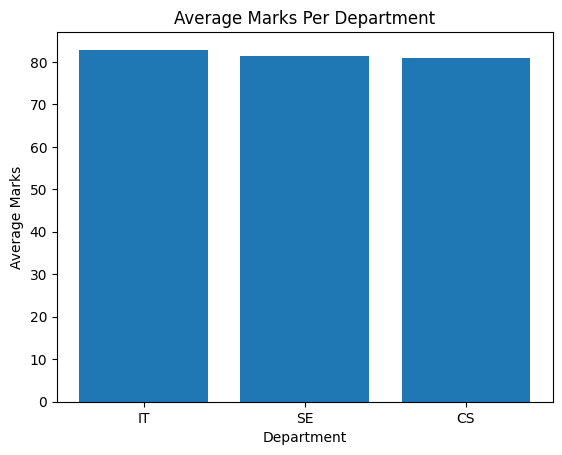

In [9]:
import matplotlib.pyplot as plt

pandas_df = avg_marks.toPandas()

plt.bar(
    pandas_df["Department"],
    pandas_df["avg(Marks)"]
)

plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.title("Average Marks Per Department")

plt.show()